# Drift Prediction - Burn-in Data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Config

In [2]:
CSV_PATH = "burn_in_dataset.csv"
SPLIT_PATH = "component_split.csv"

CHECKPOINTS = ['0h', '24h', '96h', '168h']
FEATURE_CHECKPOINTS = ['0h', '24h']
TARGET_CHECKPOINTS = ['96h', '168h']
METRICS = ['Leakage']

STRESS_COL = 'Proxy_Stress'
STRESS_LEVEL_COL = 'Stress_Level'
PART_TYPE_COL = 'Part_Type'
LABEL_COL = 'Label'
BATCH_COL = 'Batch_ID'
TIMESTAMP_PREFIX = 'Timestamp_'

## Load + clean

In [3]:
df = pd.read_csv(CSV_PATH)
split = pd.read_csv(SPLIT_PATH)
df = df.merge(split[['Component_ID','split']], on='Component_ID')
print(df.shape)

reading_cols = [f'{m}_{cp}' for m in METRICS for cp in CHECKPOINTS]
for col in reading_cols:
    bad_count = (df[col] < 0).sum()
    if bad_count:
        print(f'{col}: {bad_count} bad sensor readings')
    df.loc[df[col] < 0, col] = np.nan

target_cols_raw = [f'{m}_{cp}' for m in METRICS for cp in TARGET_CHECKPOINTS]
feature_cols_raw = [f'{m}_{cp}' for m in METRICS for cp in FEATURE_CHECKPOINTS]

before = len(df)
df = df.dropna(subset=target_cols_raw).reset_index(drop=True)
print(f'dropped {before - len(df)} rows with missing/bad targets, {len(df)} remain')

(10000, 18)
Leakage_24h: 58 bad sensor readings
Leakage_96h: 39 bad sensor readings
Leakage_168h: 27 bad sensor readings
dropped 388 rows with missing/bad targets, 9612 remain


In [4]:
for cp in CHECKPOINTS:
    df[f'{TIMESTAMP_PREFIX}{cp}'] = pd.to_datetime(df[f'{TIMESTAMP_PREFIX}{cp}'], format='ISO8601')
for cp in FEATURE_CHECKPOINTS[1:] + TARGET_CHECKPOINTS:
    df[f'elapsed_{cp}'] = (df[f'{TIMESTAMP_PREFIX}{cp}'] - df[f'{TIMESTAMP_PREFIX}0h']).dt.total_seconds() / 3600
df[['elapsed_24h','elapsed_96h','elapsed_168h']].describe()

,elapsed_24h,elapsed_96h,elapsed_168h
count,9612.000000,9612.000000,9612.000000
mean,23.996984,95.995513,168.002753
std,0.397753,0.600909,0.604302
min,22.589286,93.651873,165.642422
25%,23.729220,95.597432,167.595483
50%,23.999845,96.000369,167.993830
75%,24.264023,96.389355,168.420970
max,25.482484,98.353553,170.140073


## Reuse the shared, Batch_ID-grouped train/val/test split


In [5]:
idx_train = df.index[df['split'] == 'train']
idx_val   = df.index[df['split'] == 'val']
idx_test  = df.index[df['split'] == 'test']
label_train, label_val, label_test = df.loc[idx_train, LABEL_COL], df.loc[idx_val, LABEL_COL], df.loc[idx_test, LABEL_COL]
print(len(idx_train), 'train /', len(idx_val), 'val /', len(idx_test), 'test')

assert set(df.loc[idx_train, BATCH_COL]) & set(df.loc[idx_test, BATCH_COL]) == set(), 'train/test batch overlap!'
assert set(df.loc[idx_train, BATCH_COL]) & set(df.loc[idx_val, BATCH_COL]) == set(), 'train/val batch overlap!'

5592 train / 1880 val / 2140 test


In [6]:
imputer = SimpleImputer(strategy='median')
imputer.fit(df.loc[idx_train, feature_cols_raw])
df.loc[:, feature_cols_raw] = imputer.transform(df[feature_cols_raw])


## Features + targets


In [7]:
df['Leakage_slope'] = (df['Leakage_24h'] - df['Leakage_0h']) / df['elapsed_24h']

feature_cols_num = feature_cols_raw + [STRESS_LEVEL_COL, 'elapsed_24h', 'Leakage_slope']
cat_cols = [STRESS_COL, PART_TYPE_COL]

X_train_raw = pd.get_dummies(df.loc[idx_train, feature_cols_num + cat_cols], columns=cat_cols)
train_columns = X_train_raw.columns
X = pd.get_dummies(df[feature_cols_num + cat_cols], columns=cat_cols).reindex(columns=train_columns, fill_value=0)

y = pd.DataFrame(index=df.index)
y['Leakage_96h_log'] = np.log1p(df['Leakage_96h'])
y['Leakage_168h_log'] = np.log1p(df['Leakage_168h'])

def reconstruct(raw_preds, idx, frame=None):
    # frame defaults to the global training/val/test df (unchanged existing behaviour); pass an
    # explicit frame to reconstruct predictions for a batch that isn't part of the global df at all
    # (e.g. genuinely new components - see predict_new() near the bottom of this notebook).
    if frame is None:
        frame = df.loc[idx]
    out = pd.DataFrame(index=idx)
    out['Leakage_96h'] = np.expm1(raw_preds[:, 0])
    out['Leakage_168h'] = np.expm1(raw_preds[:, 1])
    return out[target_cols_raw]

X_train, X_val, X_test = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]
y_val_actual = df.loc[idx_val, target_cols_raw]
y_test_actual = df.loc[idx_test, target_cols_raw]

def evaluate(y_true, y_pred, name):
    print(f'--- {name} ---')
    for col in target_cols_raw:
        mae = mean_absolute_error(y_true[col], y_pred[col])
        print(f'{col:16s} MAE={mae:.4f}')
    print()

X.shape

(9612, 12)

## Baseline (reported on VAL for model selection and TEST for the final number)

In [8]:
def baseline_predict(idx):
    preds = pd.DataFrame(index=idx)
    for m in METRICS:
        v0 = df.loc[idx, f'{m}_0h']; v24 = df.loc[idx, f'{m}_24h']
        slope = (v24 - v0) / df.loc[idx, 'elapsed_24h']
        preds[f'{m}_96h'] = v24 + slope * (df.loc[idx, 'elapsed_96h'] - df.loc[idx, 'elapsed_24h'])
        preds[f'{m}_168h'] = v24 + slope * (df.loc[idx, 'elapsed_168h'] - df.loc[idx, 'elapsed_24h'])
    return preds[target_cols_raw]

baseline_val_preds = baseline_predict(idx_val)
evaluate(y_val_actual, baseline_val_preds, 'Baseline (VAL)')

--- Baseline (VAL) ---
Leakage_96h      MAE=0.3194
Leakage_168h     MAE=0.5533



## RF + GB, tuned



In [9]:
groups_train = df.loc[idx_train, BATCH_COL].values
gkf = GroupKFold(n_splits=3)

rf_grid = {'n_estimators': [150, 250], 'max_depth': [15, 25, None], 'min_samples_leaf': [1, 2, 4]}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_grid,
                                n_iter=6, cv=gkf, scoring='neg_mean_absolute_error', random_state=42, n_jobs=1)
rf_search.fit(X_train, y_train, groups=groups_train)
rf_tuned = rf_search.best_estimator_
print('best RF params:', rf_search.best_params_)
evaluate(y_val_actual, reconstruct(rf_tuned.predict(X_val), idx_val), 'Random Forest tuned (VAL)')

best RF params: {'n_estimators': 250, 'min_samples_leaf': 4, 'max_depth': 15}
--- Random Forest tuned (VAL) ---
Leakage_96h      MAE=0.1574
Leakage_168h     MAE=0.3157



In [10]:
gb_grid = {'estimator__n_estimators': [100, 150], 'estimator__learning_rate': [0.05, 0.1], 'estimator__max_depth': [2, 3]}
gb_search = RandomizedSearchCV(MultiOutputRegressor(GradientBoostingRegressor(random_state=42)), gb_grid,
                                n_iter=5, cv=gkf, scoring='neg_mean_absolute_error', random_state=42, n_jobs=1)
gb_search.fit(X_train, y_train, groups=groups_train)
gb_tuned = gb_search.best_estimator_
print('best GB params:', gb_search.best_params_)
evaluate(y_val_actual, reconstruct(gb_tuned.predict(X_val), idx_val), 'Gradient Boosting tuned (VAL)')

best GB params: {'estimator__n_estimators': 100, 'estimator__max_depth': 3, 'estimator__learning_rate': 0.05}
--- Gradient Boosting tuned (VAL) ---
Leakage_96h      MAE=0.1491
Leakage_168h     MAE=0.3008



## Tried: weighting Fail/Borderline samples higher


In [11]:
weight_options = [
    {'Safe': 1, 'Borderline': 2, 'Fail': 3},
    {'Safe': 1, 'Borderline': 5, 'Fail': 15},
]

for weights in weight_options:
    sw = label_train.map(weights).values
    rf_w = RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_leaf=4, random_state=42, n_jobs=-1)
    rf_w.fit(X_train, y_train, sample_weight=sw)
    preds = reconstruct(rf_w.predict(X_val), idx_val)

    check = pd.DataFrame({'label': label_val.values, 'true': y_val_actual['Leakage_168h'].values, 'pred': preds['Leakage_168h'].values})
    check['err'] = (check['true'] - check['pred']).abs()
    print('weights:', weights)
    print(check.groupby('label', observed=True)['err'].mean())
    print('overall MAE (VAL):', round(mean_absolute_error(y_val_actual['Leakage_168h'], preds['Leakage_168h']), 4))
    print()

weights: {'Safe': 1, 'Borderline': 2, 'Fail': 3}
label
Borderline    0.283156
Fail          1.117772
Safe          0.226979
Name: err, dtype: float64
overall MAE (VAL): 0.3559

weights: {'Safe': 1, 'Borderline': 5, 'Fail': 15}
label
Borderline    0.326670
Fail          1.065774
Safe          0.344081
Name: err, dtype: float64
overall MAE (VAL): 0.4341



## Stacked ensemble



In [12]:
gkf4 = GroupKFold(n_splits=4)

rf_base = RandomForestRegressor(n_estimators=250, max_depth=15, min_samples_leaf=4, random_state=42, n_jobs=-1)
gb_base = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42))

rf_oof = cross_val_predict(rf_base, X_train, y_train, cv=gkf4, groups=groups_train, n_jobs=1)
gb_oof = cross_val_predict(gb_base, X_train, y_train, cv=gkf4, groups=groups_train, n_jobs=1)

meta_X_train = np.hstack([rf_oof, gb_oof])
meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_X_train, y_train)

rf_base.fit(X_train, y_train)
gb_base.fit(X_train, y_train)

meta_X_val = np.hstack([rf_base.predict(X_val), gb_base.predict(X_val)])
stacked_val_preds = reconstruct(meta_model.predict(meta_X_val), idx_val)
simple_avg_val_preds = reconstruct((rf_tuned.predict(X_val) + gb_tuned.predict(X_val)) / 2, idx_val)

evaluate(y_val_actual, simple_avg_val_preds, 'Simple average ensemble (VAL)')
evaluate(y_val_actual, stacked_val_preds, 'Stacked ensemble Ridge (VAL)')

--- Simple average ensemble (VAL) ---
Leakage_96h      MAE=0.1508
Leakage_168h     MAE=0.3044

--- Stacked ensemble Ridge (VAL) ---
Leakage_96h      MAE=0.1489
Leakage_168h     MAE=0.3049



In [13]:
meta_X_test = np.hstack([rf_base.predict(X_test), gb_base.predict(X_test)])
stacked_test_preds = reconstruct(meta_model.predict(meta_X_test), idx_test)
evaluate(y_test_actual, stacked_test_preds, 'Stacked ensemble Ridge (TEST - the number to trust)')

--- Stacked ensemble Ridge (TEST - the number to trust) ---
Leakage_96h      MAE=0.1366
Leakage_168h     MAE=0.2831



## Prediction intervals (quantile regression)

In [14]:
gb_lower = MultiOutputRegressor(GradientBoostingRegressor(loss='quantile', alpha=0.05, n_estimators=150, max_depth=3, random_state=42))
gb_upper = MultiOutputRegressor(GradientBoostingRegressor(loss='quantile', alpha=0.95, n_estimators=150, max_depth=3, random_state=42))
gb_lower.fit(X_train, y_train)
gb_upper.fit(X_train, y_train)

raw_lower = gb_lower.predict(X_test)
raw_upper = gb_upper.predict(X_test)
crossed = (raw_lower > raw_upper)
print('quantile-crossing cells corrected:', int(crossed.sum()), '/', crossed.size)
raw_lower, raw_upper = np.minimum(raw_lower, raw_upper), np.maximum(raw_lower, raw_upper)

lower_preds = reconstruct(raw_lower, idx_test)
upper_preds = reconstruct(raw_upper, idx_test)

for col in target_cols_raw:
    inside = (y_test_actual[col] >= lower_preds[col]) & (y_test_actual[col] <= upper_preds[col])
    print(f'{col:16s} coverage={inside.mean():.1%}  avg width={ (upper_preds[col]-lower_preds[col]).mean():.4f}')

quantile-crossing cells corrected: 1 / 4280
Leakage_96h      coverage=88.7%  avg width=0.4077
Leakage_168h     coverage=89.2%  avg width=1.1316


In [15]:
df_test = df.loc[idx_test].copy()
for m in METRICS:
    step = (df_test[f'{m}_168h'] - df_test[f'{m}_96h']).abs()
    typical = df.loc[idx_train, f'{m}_96h'].sub(df.loc[idx_train, f'{m}_24h']).abs().median()
    suspicious = (step > 10 * typical).values
    for target_col in [f'{m}_96h', f'{m}_168h']:
        width = (upper_preds[target_col] - lower_preds[target_col]).values
        if suspicious.sum() > 0:
            print(f'{target_col:16s} normal_avg_width={width[~suspicious].mean():.4f}  '
                  f'suspicious_avg_width={width[suspicious].mean():.4f}  (n_suspicious={suspicious.sum()})')
        else:
            print(f'{target_col:16s} no suspicious rows in this split')

Leakage_96h      normal_avg_width=0.3742  suspicious_avg_width=0.9575  (n_suspicious=123)
Leakage_168h     normal_avg_width=1.0798  suspicious_avg_width=1.9804  (n_suspicious=123)


## Explicit safety-slope early-rejection rule


In [16]:
def drift_rate(v24, v168, elapsed_24h, elapsed_168h):
    return (v168 - v24) / (elapsed_168h - elapsed_24h)

safe_train_mask = (label_train == 'Safe').values
safety_slope = {}
for m in METRICS:
    rate = drift_rate(
        df.loc[idx_train, f'{m}_24h'].values, df.loc[idx_train, f'{m}_168h'].values,
        df.loc[idx_train, 'elapsed_24h'].values, df.loc[idx_train, 'elapsed_168h'].values,
    )
    safety_slope[m] = float(np.percentile(np.abs(rate[safe_train_mask]), 99))
print('Safety slope thresholds (units/hour, from Safe TRAIN rows only):')
for m, v in safety_slope.items():
    print(f'  {m:12s} {v:.5f}')

pred_rate_test = pd.DataFrame(index=idx_test)
for m in METRICS:
    rate = drift_rate(
        df.loc[idx_test, f'{m}_24h'].values, stacked_test_preds[f'{m}_168h'].values,
        df.loc[idx_test, 'elapsed_24h'].values, df.loc[idx_test, 'elapsed_168h'].values,
    )
    pred_rate_test[m] = np.abs(rate)

slope_reject_flag = pd.Series(False, index=idx_test)
for m in METRICS:
    slope_reject_flag |= (pred_rate_test[m] > safety_slope[m])

print(f'\nEarly-rejection flag raised on {int(slope_reject_flag.sum())} / {len(slope_reject_flag)} TEST components')

fail_mask_test = (label_test == 'Fail').values
safe_mask_test = (label_test == 'Safe').values
if fail_mask_test.any():
    recall = slope_reject_flag.values[fail_mask_test].mean()
    print(f'Recall on true FAIL (this rule alone):        {recall:.1%}')
false_alarm = slope_reject_flag.values[safe_mask_test].mean()
print(f'False-alarm rate on true SAFE (this rule alone): {false_alarm:.1%}')

Safety slope thresholds (units/hour, from Safe TRAIN rows only):
  Leakage      0.00653

Early-rejection flag raised on 334 / 2140 TEST components
Recall on true FAIL (this rule alone):        57.5%
False-alarm rate on true SAFE (this rule alone): 4.1%


## Score genuinely new components (only 0h/24h exist yet - no 96h/168h)

Everything above trains and evaluates on the full historical dataset, which has all four
checkpoints - that's normal and correct for training. But a component actually being screened
*right now* only has `0h`/`24h` readings; `96h`/`168h` are exactly what this module predicts,
so a caller can never be expected to supply them (and `Traditional_Test_Result`/`Label` don't
exist yet either). `predict_new()` below is the function the backend should actually call for
live scoring - it only touches `0h`/`24h` fields plus the categorical/id columns, and returns
predictions in the same `Pred_{metric}_168h`-style shape everything downstream already expects.

In [17]:
# The actual 168h checkpoint won't land exactly on hour 168 (sensor/scheduling jitter, same as
# elapsed_24h above) - but for a component that hasn't gotten there yet, the planned duration IS
# the best estimate, so we learn it from history once and reuse it as a constant at inference time.
NOMINAL_ELAPSED_168H = float(df.loc[idx_train, 'elapsed_168h'].median())
print(f'NOMINAL_ELAPSED_168H = {NOMINAL_ELAPSED_168H:.2f}h (median actual elapsed time to the 168h '
      f'checkpoint across TRAIN, used as the assumed duration for components still in progress)')

def predict_new(raw_df_new):
    """Score components that are still mid-burn-in: only Timestamp_0h/24h and
    {Leakage}_0h/24h are required, plus Stress_Level/Proxy_Stress/Part_Type.
    No 96h, no 168h, no Traditional_Test_Result, no Label, no Batch-based split needed.
    Returns (preds, lower, upper, slope_reject_flag) with the same column shape as the
    TEST-time predictions above (Pred columns via reconstruct()).
    """
    d = raw_df_new.copy()
    d['Timestamp_0h'] = pd.to_datetime(d['Timestamp_0h'], format='ISO8601')
    d['Timestamp_24h'] = pd.to_datetime(d['Timestamp_24h'], format='ISO8601')
    d['elapsed_24h'] = (d['Timestamp_24h'] - d['Timestamp_0h']).dt.total_seconds() / 3600

    for col in feature_cols_raw:
        d.loc[d[col] < 0, col] = np.nan
    d.loc[:, feature_cols_raw] = imputer.transform(d[feature_cols_raw])

    d['Leakage_slope'] = (d['Leakage_24h'] - d['Leakage_0h']) / d['elapsed_24h']

    Xn = pd.get_dummies(d[feature_cols_num + cat_cols], columns=cat_cols)
    Xn = Xn.reindex(columns=train_columns, fill_value=0)

    rf_p, gb_p = rf_base.predict(Xn), gb_base.predict(Xn)
    stacked = meta_model.predict(np.hstack([rf_p, gb_p]))
    raw_lower, raw_upper = gb_lower.predict(Xn), gb_upper.predict(Xn)
    raw_lower, raw_upper = np.minimum(raw_lower, raw_upper), np.maximum(raw_lower, raw_upper)

    preds = reconstruct(stacked, d.index, frame=d)
    lower = reconstruct(raw_lower, d.index, frame=d)
    upper = reconstruct(raw_upper, d.index, frame=d)

    d['elapsed_168h'] = NOMINAL_ELAPSED_168H  # burn-in isn't finished - use the planned duration
    slope_reject_flag = pd.Series(False, index=d.index)
    for m in METRICS:
        rate = drift_rate(d[f'{m}_24h'].values, preds[f'{m}_168h'].values,
                           d['elapsed_24h'].values, d['elapsed_168h'].values)
        slope_reject_flag |= (np.abs(rate) > safety_slope[m])

    return preds, lower, upper, slope_reject_flag

# --- demo: a batch that ONLY has 0h/24h, exactly like a real in-progress component ---
demo_new = df.loc[idx_test].sample(10, random_state=3).drop(
    columns=[c for c in df.columns if c.endswith('_96h') or c.endswith('_168h')]
            + ['Traditional_Test_Result', 'Label', 'split'],
    errors='ignore',
)
print('demo_new columns:', list(demo_new.columns))
demo_preds, demo_lower, demo_upper, demo_flag = predict_new(demo_new)
demo_preds['Slope_Reject_Flag'] = demo_flag.values
demo_preds


NOMINAL_ELAPSED_168H = 168.00h (median actual elapsed time to the 168h checkpoint across TRAIN, used as the assumed duration for components still in progress)
demo_new columns: ['Component_ID', 'Batch_ID', 'Part_Type', 'Part_Family', 'Proxy_Stress', 'Stress_Level', 'Stress_Unit', 'Timestamp_0h', 'Timestamp_24h', 'Leakage_0h', 'Leakage_24h', 'elapsed_24h', 'Leakage_slope']


,Leakage_96h,Leakage_168h,Slope_Reject_Flag
3487,1.304294,1.560309,False
807,0.590832,0.680195,False
699,1.121488,1.568208,False
6342,0.935828,1.140771,False
8378,0.499389,0.617853,False
2667,0.467556,0.527332,False
2346,0.259389,0.363589,False
7011,1.001472,1.133922,False
1583,1.224329,1.585571,False
5781,1.053260,1.413967,False


## Which features matter (from RF)

In [18]:
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

,0
Leakage_24h,0.645672
Leakage_slope,0.268261
Leakage_0h,0.030009
elapsed_24h,0.024034
Stress_Level,0.022103
Part_Type_Op-Amp IC,0.002813
Proxy_Stress_Thermal-High,0.002126
Part_Type_Voltage Regulator IC,0.001853
Part_Type_MOSFET,0.001013
Part_Type_Digital Logic IC,0.000947


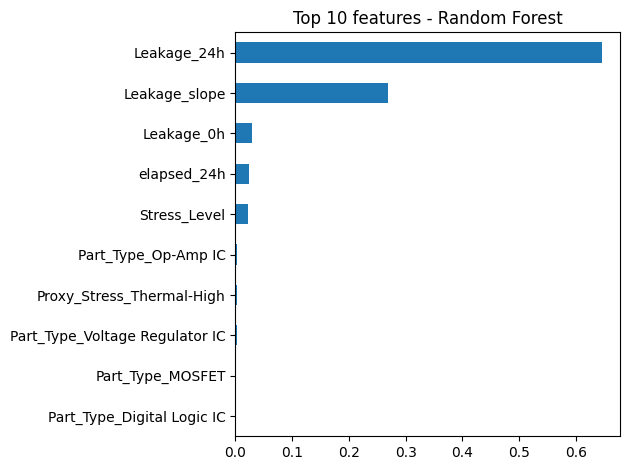

In [19]:
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 features - Random Forest')
plt.tight_layout()
plt.show()

## Error by label (TEST, the final model)

In [20]:
check = pd.DataFrame({
    'Label': label_test.values,
    'true': y_test_actual['Leakage_168h'].values,
    'pred': stacked_test_preds['Leakage_168h'].values,
})
check['abs_error'] = (check['true'] - check['pred']).abs()
check.groupby('Label', observed=True)['abs_error'].mean().sort_values(ascending=False)

,abs_error
Label,
Fail,1.138012
Borderline,0.242602
Safe,0.152638


## Save everything


In [21]:
import joblib
joblib.dump({
    'rf': rf_base, 'gb': gb_base, 'meta_model': meta_model,
    'quantile_lower': gb_lower, 'quantile_upper': gb_upper,
    'imputer': imputer, 'feature_cols_raw': feature_cols_raw,
    'feature_columns': list(X.columns),
    'safety_slope': safety_slope,
    'nominal_elapsed_168h': NOMINAL_ELAPSED_168H,  # for scoring components still mid burn-in
    'feature_cols_num': feature_cols_num,
    'cat_cols': cat_cols,
    'train_columns': list(train_columns),
}, 'drift_prediction_models.joblib')
print('saved')

saved
